# HELIX Revenue Prediction

## Notebook 04 — Bivariate Analysis

Objective

Analyze relationships between features and the target variable.

In [1]:
# import library
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
# load dataset
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_customer_behavior_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

In [3]:
# feature
target = "Total_Amount"

numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns if col != target
]

categorical_cols = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Device_Type",
    "Is_Returning_Customer",
]

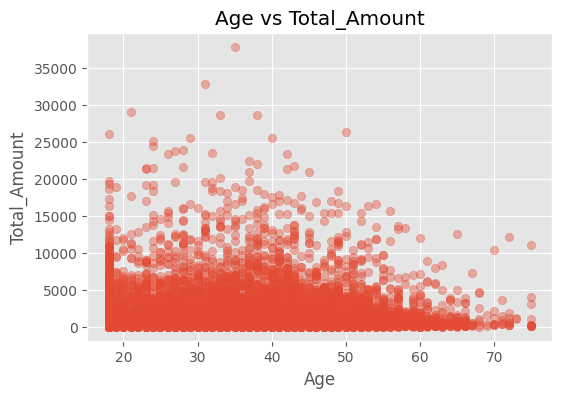

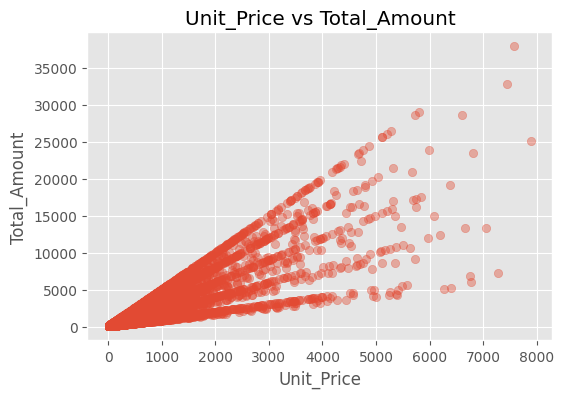

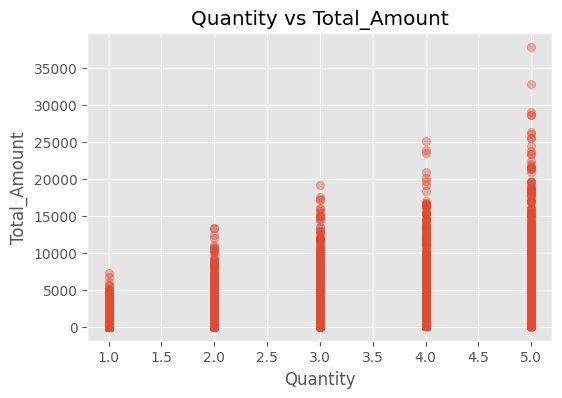

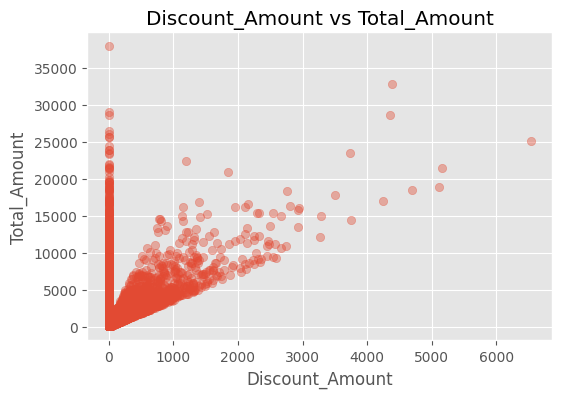

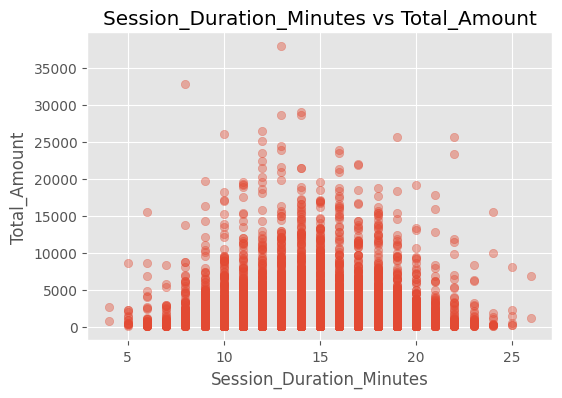

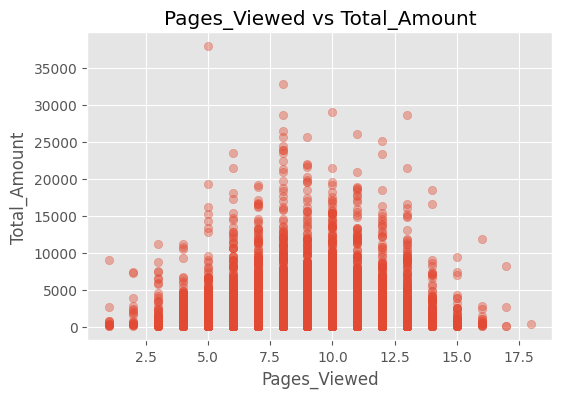

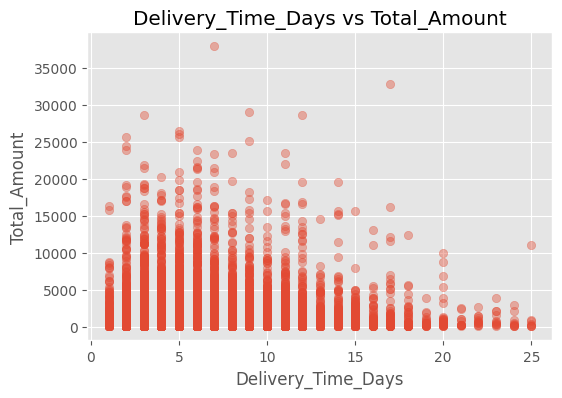

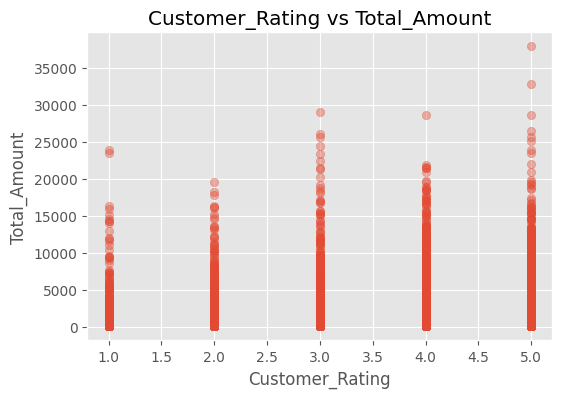

In [4]:
# numerical vs target
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    plt.scatter(df[col], df[target], alpha=0.4)

    plt.xlabel(col)

    plt.ylabel(target)

    plt.title(f"{col} vs {target}")

    plt.show()

Total_Amount                1.000000
Unit_Price                  0.866225
Discount_Amount             0.456245
Quantity                    0.256567
Pages_Viewed                0.008851
Customer_Rating             0.000879
Age                        -0.003606
Session_Duration_Minutes   -0.008717
Delivery_Time_Days         -0.015784
Name: Total_Amount, dtype: float64


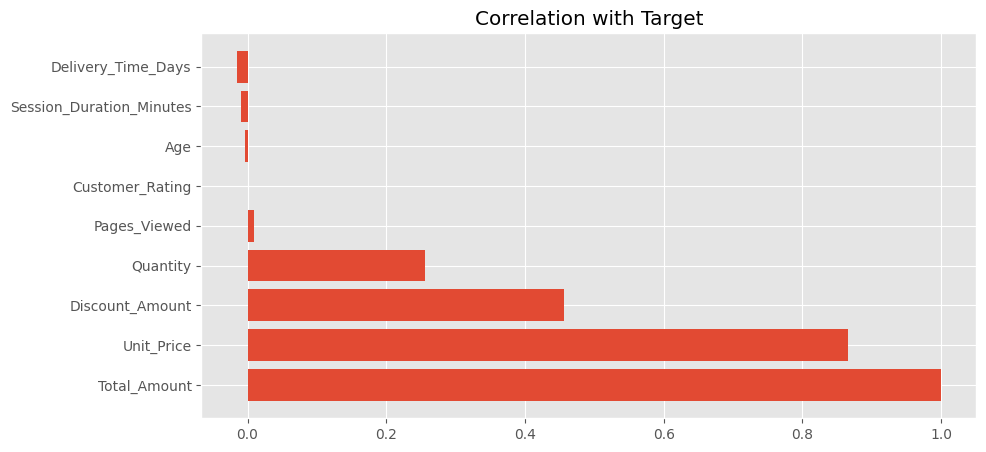

In [6]:
# correlation analysis
corr = (
    df[numeric_cols + [target]]
    .corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

print(corr)

plt.figure(figsize=(10, 5))

plt.barh(corr.index, corr.values)

plt.title("Correlation with Target")

plt.show()

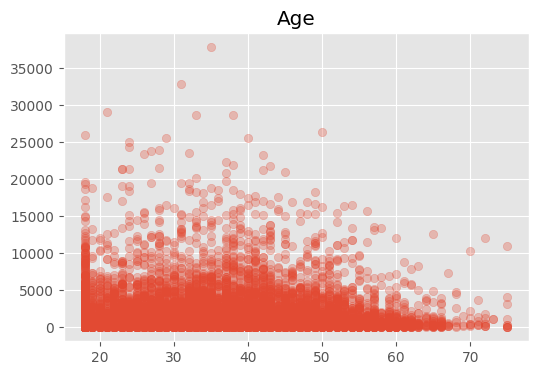

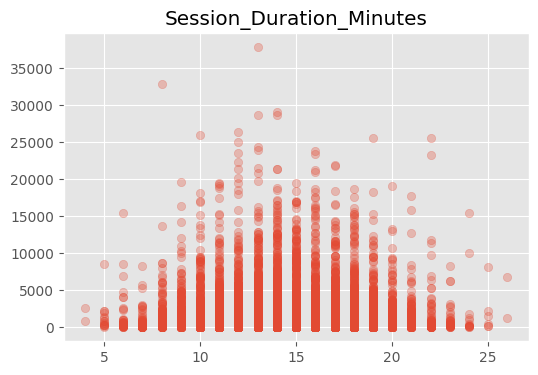

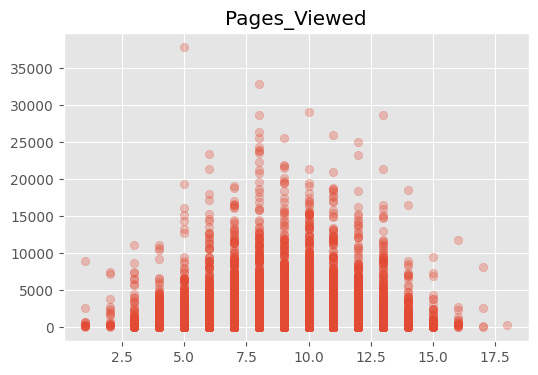

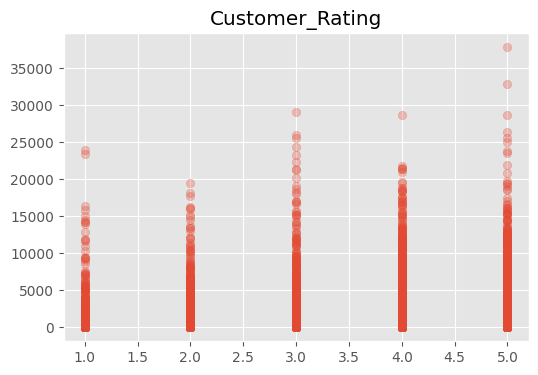

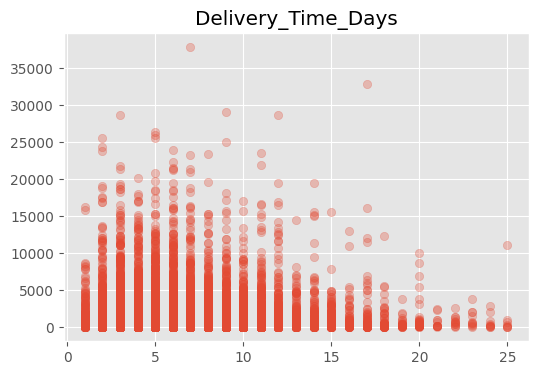

In [7]:
# scatter plot
important = [
    "Age",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Customer_Rating",
    "Delivery_Time_Days",
]

for col in important:
    plt.figure(figsize=(6, 4))

    plt.scatter(df[col], df[target], alpha=0.3)

    plt.title(col)

    plt.show()

In [8]:
# categorical vs target
for col in categorical_cols:
    summary = df.groupby(col)[target].agg(["count", "mean", "median", "std"]).round(2)

    print("=" * 70)

    print(col)

    print(summary)

Gender
        count     mean  median      std
Gender                                 
Female   8613  1281.55  463.94  2321.61
Male     8176  1265.07  450.15  2360.71
Other     260  1530.32  482.78  3305.82
City
           count     mean  median      std
City                                      
Adana       1326  1140.51  408.69  2002.31
Ankara      2422  1260.30  428.98  2404.50
Antalya     1246  1333.54  473.92  2504.64
Bursa       1721  1346.33  484.40  2561.19
Eskisehir    706  1287.67  491.55  2137.53
Gaziantep   1183  1330.03  467.01  2610.65
Istanbul    4402  1282.73  453.96  2345.54
Izmir       2072  1279.80  465.20  2308.33
Kayseri      851  1282.79  517.50  2101.52
Konya       1120  1217.10  416.96  2334.55
Product_Category
                  count     mean   median      std
Product_Category                                  
Beauty             2212   313.94   235.14   259.67
Books              2206   163.37   121.91   139.75
Electronics        2074  5053.95  3600.66  4578.04


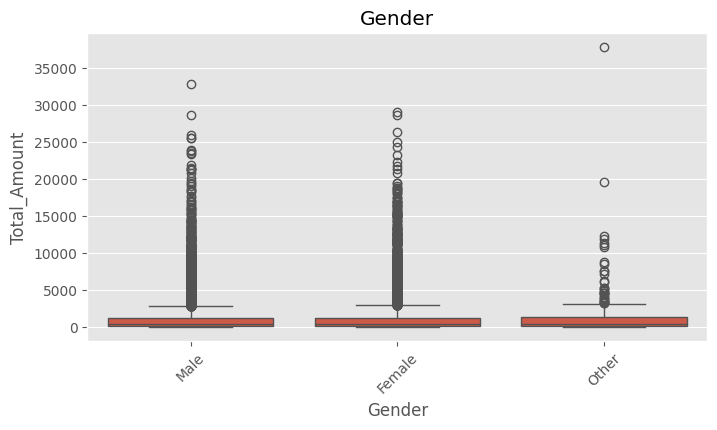

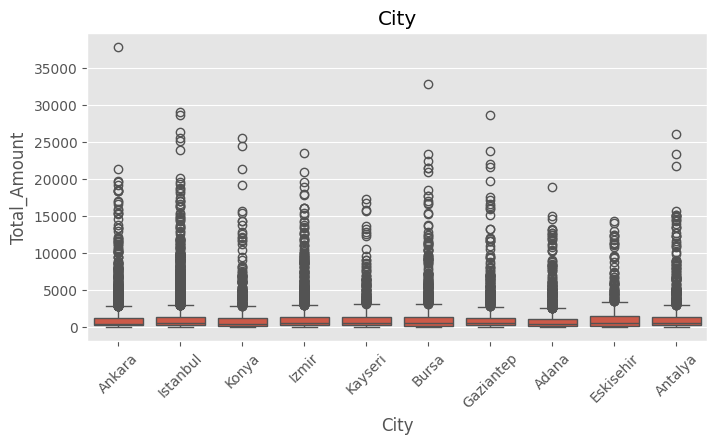

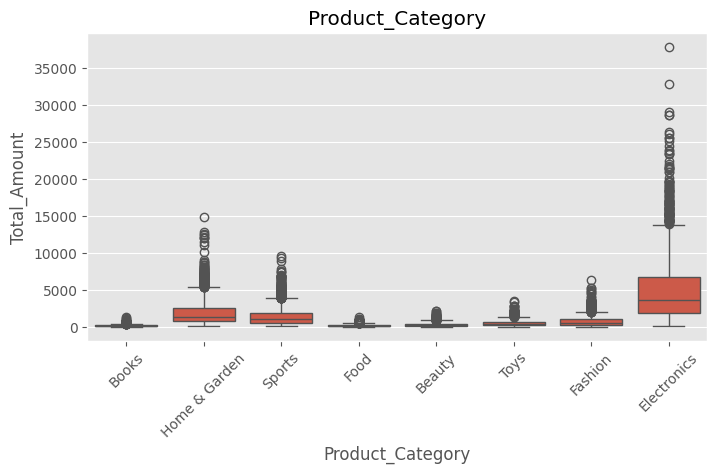

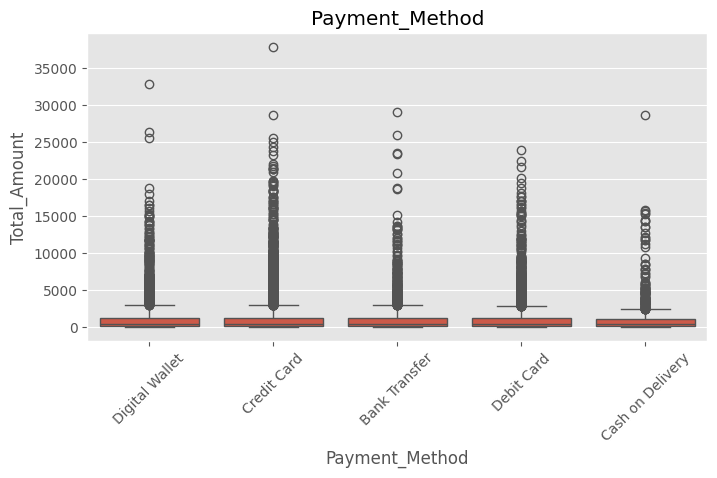

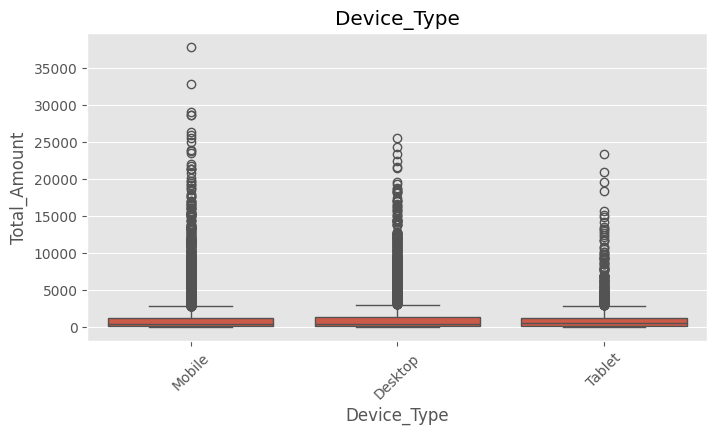

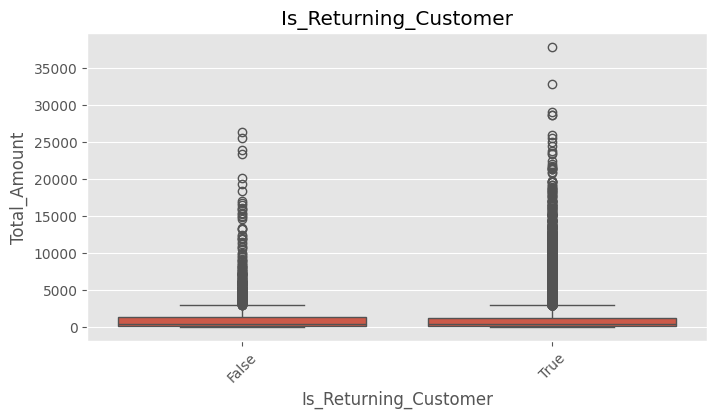

In [9]:
# boxplot
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=col, y=target)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

In [10]:
# mann whitney u analysis
from scipy.stats import kruskal, mannwhitneyu

binary_features = ["Gender", "Is_Returning_Customer"]

for col in binary_features:
    groups = [g[target].values for _, g in df.groupby(col)]

    stat, p = mannwhitneyu(groups[0], groups[1])

    print(f"{col}: p-value = {p:.6f}")

Gender: p-value = 0.214659
Is_Returning_Customer: p-value = 0.888073


In [ ]:
# kruskal wallis analysis
multi_features = ["City", "Product_Category", "Payment_Method", "Device_Type"]

for col in multi_features:
    groups = [g[target].values for _, g in df.groupby(col)]

    stat, p = kruskal(*groups)

    print(f"{col}: p-value = {p:.6f}")

City: p-value = 0.103182
Product_Category: p-value = 0.000000
Payment_Method: p-value = 0.068539
Device_Type: p-value = 0.567393


In [12]:
# relationship strength
ranking = pd.DataFrame({"Correlation": corr.abs()})

ranking = ranking.sort_values("Correlation", ascending=False)

print(ranking)

                          Correlation
Total_Amount                 1.000000
Unit_Price                   0.866225
Discount_Amount              0.456245
Quantity                     0.256567
Delivery_Time_Days           0.015784
Pages_Viewed                 0.008851
Session_Duration_Minutes     0.008717
Age                          0.003606
Customer_Rating              0.000879


In [13]:
# feature ranking
def strength(v):
    if v >= 0.8:
        return "Very Strong"

    elif v >= 0.6:
        return "Strong"

    elif v >= 0.4:
        return "Moderate"

    elif v >= 0.2:
        return "Weak"

    return "Very Weak"


ranking["Strength"] = ranking["Correlation"].apply(strength)

print(ranking)

                          Correlation     Strength
Total_Amount                 1.000000  Very Strong
Unit_Price                   0.866225  Very Strong
Discount_Amount              0.456245     Moderate
Quantity                     0.256567         Weak
Delivery_Time_Days           0.015784    Very Weak
Pages_Viewed                 0.008851    Very Weak
Session_Duration_Minutes     0.008717    Very Weak
Age                          0.003606    Very Weak
Customer_Rating              0.000879    Very Weak


## Business Insights

### Customer

- Determine whether age influences revenue.
- Evaluate spending behavior between new and returning customers.

### Product

- Identify product categories associated with higher transaction values.

### Geography

- Compare revenue performance across cities.

### Customer Behavior

- Investigate whether browsing behavior is associated with higher purchase values.

### Transaction

- Confirm whether transaction-related variables introduce target leakage.

## Modeling Recommendation

Two modeling scenarios are proposed.

### Model A

Business Prediction

Drop:

- Unit_Price
- Quantity
- Discount_Amount

This model estimates revenue before transaction completion.

---

### Model B

Transaction Estimation

Include:

- Unit_Price
- Quantity
- Discount_Amount

This model estimates transaction totals after purchase information becomes available.

Both models will be compared during the modeling phase.